In [47]:
#%pip install merlinquantum torch numpy matplotlib

In [48]:
import math
import importlib
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# MerLin package import name is usually `merlin`.
try:
    import merlin as ML
except Exception as exc:
    raise ImportError(
        "Could not import MerLin. Install with: pip install merlinquantum"
    ) from exc

print("torch", torch.__version__)
print("merlin", getattr(ML, "__version__", "version unknown"))

torch 2.10.0+cpu
merlin 0.2.3


In [49]:
# Reproducibility and dtype
seed = 1234
torch.manual_seed(seed)
np.random.seed(seed)

# MerLin's high-level layers commonly return float32 tensors.
# Keep the whole notebook in float32 to avoid errors such as:
# RuntimeError: mat1 and mat2 must have the same dtype, but got Float and Double
torch.set_default_dtype(torch.float32)
dtype = torch.float32

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("dtype:", dtype)


device: cpu
dtype: torch.float32


In [50]:
# PDE constants
alpha = 0.1
x_min, x_max = 0.0, 1.0
t_min, t_max = 0.0, 1.0

def exact_u(x, t):
    return torch.exp(-alpha * math.pi**2 * t) * torch.sin(math.pi * x)

def sample_interior(n):
    x = torch.rand(n, 1, device=device, dtype=torch.get_default_dtype())
    t = torch.rand(n, 1, device=device, dtype=torch.get_default_dtype())
    xt = torch.cat([x, t], dim=1)
    xt.requires_grad_(True)
    return xt

def sample_initial(n):
    x = torch.rand(n, 1, device=device, dtype=torch.get_default_dtype())
    t = torch.zeros_like(x)
    xt = torch.cat([x, t], dim=1)
    return xt

def sample_boundary(n):
    t = torch.rand(n, 1, device=device, dtype=torch.get_default_dtype())
    half = n // 2
    x0 = torch.zeros(half, 1, device=device, dtype=torch.get_default_dtype())
    x1 = torch.ones(n - half, 1, device=device, dtype=torch.get_default_dtype())
    x = torch.cat([x0, x1], dim=0)
    xt = torch.cat([x, t], dim=1)
    return xt

In [51]:
class MerlinHeatQPINN(nn.Module):
    """Simple high-level MerLin baseline kept from the original notebook.

    The actual models trained below are MerlinHeatQPINNCustom instances,
    which use the simple MerLin-native minimal-encoding DV circuit with
    three photons and a variable number of modes.
    """
    def __init__(self, feature_size=4, quantum_output_size=4, hidden=16):
        super().__init__()
        self.feature_map = nn.Sequential(
            nn.Linear(2, hidden),
            nn.Tanh(),
            nn.Linear(hidden, feature_size),
        )

        self.quantum = ML.QuantumLayer.simple(
            input_size=feature_size,
            output_size=quantum_output_size,
        )

        self.readout = nn.Sequential(
            nn.Linear(quantum_output_size, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 2),
        )

    def forward(self, xt):
        x = xt[:, 0:1]
        z = self.feature_map(xt)
        q = self.quantum(z)
        out = self.readout(q)

        q_u = out[:, 0:1]
        ux_hat = out[:, 1:2]

        # Enforce homogeneous Dirichlet boundary conditions exactly.
        u = x * (1.0 - x) * q_u
        return u, ux_hat


In [52]:
import torch
import torch.nn as nn
import perceval as pcvl
import merlin as ML


N_PHOTONS = 3
MODE_VALUES = list(range(3, 16))


def balanced_input_state(n_modes, n_photons=N_PHOTONS):
    """Place one photon in the first `n_photons` modes."""
    if n_photons > n_modes:
        raise ValueError("n_photons cannot exceed n_modes for this input pattern")
    return [1] * n_photons + [0] * (n_modes - n_photons)


def add_fixed_brickwork(circ, n_modes):
    """
    Fixed shallow preparation mesh.

    Brickwork pattern:
        even pairs: (0,1), (2,3), ...
        odd pairs:  (1,2), (3,4), ...

    This spreads the initial Fock state before the first phase encoding,
    so the first data phase is observable rather than only a global phase.
    """
    # Even pairs
    for m in range(0, n_modes - 1, 2):
        circ.add((m, m + 1), pcvl.BS.Rx(theta=np.pi / 2))

    # Odd pairs
    for m in range(1, n_modes - 1, 2):
        circ.add((m, m + 1), pcvl.BS.Rx(theta=np.pi / 2))


def add_trainable_brickwork(circ, n_modes, block_name):
    """Trainable shallow interferometer block with the same brickwork pattern."""
    # Even pairs
    for j, m in enumerate(range(0, n_modes - 1, 2)):
        circ.add(
            (m, m + 1),
            pcvl.BS.Rx(
                theta=pcvl.P(f"gamma_{block_name}_even_{j}"),
                phi_tr=pcvl.P(f"phi_{block_name}_even_{j}"),
            ),
        )

    # Odd pairs
    for j, m in enumerate(range(1, n_modes - 1, 2)):
        circ.add(
            (m, m + 1),
            pcvl.BS.Rx(
                theta=pcvl.P(f"gamma_{block_name}_odd_{j}"),
                phi_tr=pcvl.P(f"phi_{block_name}_odd_{j}"),
            ),
        )


def orthogonal_relative_patterns(n_modes):
    """
    Return two zero-sum, orthogonal integer phase patterns for x and t.

    For 5 modes, this reproduces the earlier relative-phase choice:
        x: ( 1,  1, 0, -1, -1)
        t: ( 1, -1, 0, -1,  1)

    For larger mode counts, the same idea is extended symmetrically.
    The patterns remain zero-sum and orthogonal, so x and t occupy two
    independent relative-phase directions rather than a global phase.
    """
    if n_modes < 3:
        raise ValueError("orthogonal encoding requires at least 3 modes")

    # Special smallest case: two independent zero-sum directions in 3 modes.
    if n_modes == 3:
        vx = [1, -1, 0]
        vt = [1, 1, -2]
        return vx, vt

    k = n_modes // 2
    middle = [0] if n_modes % 2 else []

    # x: positive first half, optional zero middle, negative second half.
    vx = [1] * k + middle + [-1] * k

    # Build a zero-sum vector on one half: [1,-1,1,-1,...] with a trailing 0
    # if the half has odd length. Mirror it with opposite sign on the other half.
    a = []
    for _ in range(k // 2):
        a.extend([1, -1])
    if k % 2:
        a.append(0)
    vt = a + middle + [-v for v in a]

    # Sanity checks: both are zero-sum and mutually orthogonal.
    assert sum(vx) == 0
    assert sum(vt) == 0
    assert sum(ax * at for ax, at in zip(vx, vt)) == 0
    return vx, vt


def positive_equivalent_pattern(relative_pattern):
    """
    Shift an integer relative-phase vector to a nonnegative equivalent.

    Adding the same phase to all modes is a physically irrelevant global phase
    in a fixed-photon circuit, so shifting every coefficient by the same amount
    leaves the encoded relative phases unchanged. Nonnegative coefficients let
    us implement the pattern using repeated PS(input) gates without relying on
    symbolic negative or multiplied parameters.
    """
    offset = -min(relative_pattern)
    return [int(v + offset) for v in relative_pattern]


def add_repeated_phase_encoding(circ, parameter, positive_pattern):
    """Implement a nonnegative integer phase pattern using repeated PS gates."""
    for mode, repeats in enumerate(positive_pattern):
        for _ in range(repeats):
            circ.add(mode, pcvl.PS(parameter))


def build_orthogonal_encoding_circuit(n_modes):
    """
    Scalable MerLin-native DV photonic circuit with orthogonal encoding.

    Architecture for three photons in `n_modes` modes:
        |1,1,1,0,...,0>
        -> fixed shallow preparation mesh
        -> orthogonal relative-phase encoding of x
        -> trainable shallow mesh U1
        -> orthogonal relative-phase encoding of t
        -> trainable shallow mesh U2
        -> photon-count probabilities
    """
    x = pcvl.P("input0")
    t = pcvl.P("input1")

    vx_rel, vt_rel = orthogonal_relative_patterns(n_modes)
    vx_pos = positive_equivalent_pattern(vx_rel)
    vt_pos = positive_equivalent_pattern(vt_rel)

    circ = pcvl.Circuit(n_modes, name=f"DV_native_3photons_{n_modes}modes_orthogonal_encoding")

    # Fixed preparation mixing
    add_fixed_brickwork(circ, n_modes)

    # First data encoding: x in one relative-phase direction
    add_repeated_phase_encoding(circ, x, vx_pos)

    # First trainable interferometer
    add_trainable_brickwork(circ, n_modes, block_name="U1")

    # Second data encoding: t in an orthogonal relative-phase direction
    add_repeated_phase_encoding(circ, t, vt_pos)

    # Second trainable interferometer
    add_trainable_brickwork(circ, n_modes, block_name="U2")

    return circ


In [53]:
class MerlinHeatQPINNCustom(nn.Module):
    def __init__(self, n_modes, hidden=16):
        super().__init__()

        self.n_modes = n_modes
        self.input_state = balanced_input_state(n_modes)
        self.x_pattern, self.t_pattern = orthogonal_relative_patterns(n_modes)

        self.feature_map = nn.Sequential(
            nn.Linear(2, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 2),
            nn.Tanh(),
        )

        circ = build_orthogonal_encoding_circuit(n_modes)
        self.circuit_to_draw = circ

        self.quantum = ML.QuantumLayer(
            input_size=2,
            circuit=circ,
            input_parameters=["input"],
            trainable_parameters=["gamma", "phi"],
            input_state=self.input_state,
            # Keep the full Fock distribution for 3 photons in `n_modes` modes.
            measurement_strategy=ML.MeasurementStrategy.probs(ML.ComputationSpace.FOCK),
        )

        self.readout = nn.Sequential(
            nn.Linear(self.quantum.output_size, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 2),
        )

    def forward(self, xt):
        x = xt[:, 0:1]

        # The feature map produces two angle-like inputs. Scaling by pi keeps the
        # values in a physically meaningful range, approximately [-pi, pi].
        z = math.pi * self.feature_map(xt)

        # Photon-count probability features from the full Fock space.
        q = self.quantum(z)
        out = self.readout(q)

        q_u = out[:, 0:1]
        ux_hat = out[:, 1:2]

        # Enforce homogeneous Dirichlet boundary conditions exactly.
        u = x * (1.0 - x) * q_u
        return u, ux_hat


In [54]:
def make_model(n_modes):
    model = MerlinHeatQPINNCustom(n_modes=n_modes).to(device=device, dtype=dtype)

    # Defensive dtype alignment: if MerLin creates/returns float32 internally,
    # the surrounding PyTorch layers must also be float32.
    for p in model.parameters():
        if p.is_floating_point():
            p.data = p.data.to(dtype)
    return model


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Quick check of the model family before the sweep
example_model = make_model(n_modes=5)
print("example mode count:", example_model.n_modes)
print("example input state:", example_model.input_state)
print("x relative-phase pattern:", example_model.x_pattern)
print("t relative-phase pattern:", example_model.t_pattern)
print("example quantum output size:", example_model.quantum.output_size)
print("example trainable parameters:", count_trainable_parameters(example_model))


example mode count: 5
example input state: [1, 1, 1, 0, 0]
x relative-phase pattern: [1, 1, 0, -1, -1]
t relative-phase pattern: [1, -1, 0, -1, 1]
example quantum output size: 35
example trainable parameters: 708


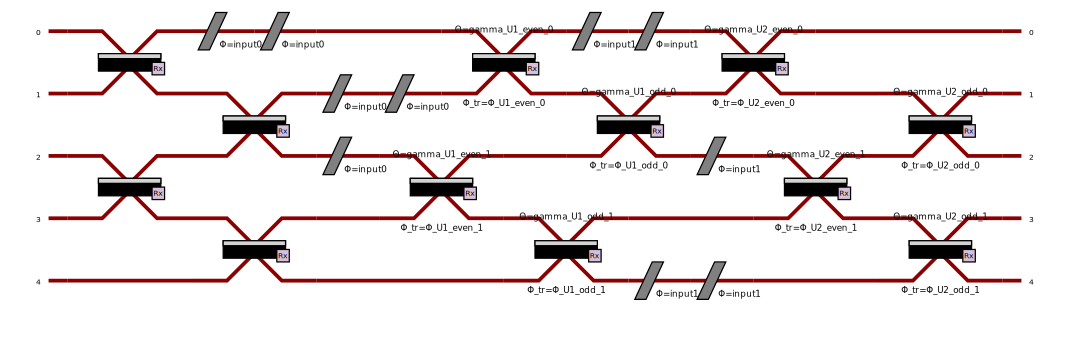

In [55]:
# Example circuit from the family: three photons in five modes with orthogonal encoding
pcvl.pdisplay(example_model.circuit_to_draw, recursive=False)


In [56]:
def gradients(y, x):
    return torch.autograd.grad(
        y,
        x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]


def pde_and_consistency_residuals(model, xt):
    u, ux_hat = model(xt)

    grad_u = gradients(u, xt)
    u_x = grad_u[:, 0:1]
    u_t = grad_u[:, 1:2]

    grad_ux_hat = gradients(ux_hat, xt)
    ux_hat_x = grad_ux_hat[:, 0:1]

    pde_residual = u_t - alpha * ux_hat_x
    consistency_residual = u_x - ux_hat
    return pde_residual, consistency_residual

In [57]:
# Loss weights and sweep settings
n_f = 64      # interior points
n_i = 64      # initial condition points
n_b = 64      # boundary points, mostly redundant due to hard BC but kept as a check

epochs = 300
lr = 1e-2
lambda_f = 1.0
lambda_c = 1.0   # stronger consistency term for the auxiliary derivative output
lambda_i = 10.0
lambda_b = 1.0

mse = nn.MSELoss()


def reset_seed(seed_value=seed):
    torch.manual_seed(seed_value)
    np.random.seed(seed_value)


def train_one_model(n_modes, verbose=False):
    """Train one model for the requested number of modes."""
    reset_seed(seed)
    model = make_model(n_modes)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        xt_f = sample_interior(n_f)
        xt_i = sample_initial(n_i)
        xt_b = sample_boundary(n_b)

        # Physics and consistency losses
        r_f, r_c = pde_and_consistency_residuals(model, xt_f)
        loss_f = mse(r_f, torch.zeros_like(r_f))
        loss_c = mse(r_c, torch.zeros_like(r_c))

        # Initial condition loss
        u_i, _ = model(xt_i)
        x_i = xt_i[:, 0:1]
        t_i = xt_i[:, 1:2]
        loss_i = mse(u_i, exact_u(x_i, t_i))

        # Boundary loss: should already be near zero by construction.
        u_b, _ = model(xt_b)
        loss_b = mse(u_b, torch.zeros_like(u_b))

        loss = lambda_f * loss_f + lambda_c * loss_c + lambda_i * loss_i + lambda_b * loss_b
        loss.backward()
        optimizer.step()

        history.append([loss.item(), loss_f.item(), loss_c.item(), loss_i.item(), loss_b.item()])

        if verbose and (epoch == 1 or epoch % 25 == 0):
            print(
                f"epoch {epoch:04d} | loss={loss.item():.4e} | "
                f"pde={loss_f.item():.2e} | cons={loss_c.item():.2e} | "
                f"ic={loss_i.item():.2e} | bc={loss_b.item():.2e}"
            )

    return model, np.array(history)


In [58]:
# Sweep over mode counts for a fixed three-photon input
sweep_results = []
best_model = None
best_history = None
best_rel_l2 = float("inf")
best_n_modes = None

for n_modes in MODE_VALUES:
    print("=" * 72)
    print(f"Training 3-photon model with {n_modes} mode(s)")

    model, history = train_one_model(n_modes=n_modes, verbose=False)

    # Evaluate relative L2 on the common grid
    nx, nt = 60, 60
    x = torch.linspace(0, 1, nx, device=device, dtype=dtype).reshape(-1, 1)
    t = torch.linspace(0, 1, nt, device=device, dtype=dtype).reshape(-1, 1)
    X, T = torch.meshgrid(x.squeeze(), t.squeeze(), indexing="ij")
    xt_grid = torch.stack([X.reshape(-1), T.reshape(-1)], dim=1)

    with torch.no_grad():
        U_pred_tmp, _ = model(xt_grid)
        U_pred_tmp = U_pred_tmp.reshape(nx, nt).cpu()
        U_true_tmp = exact_u(xt_grid[:, 0:1], xt_grid[:, 1:2]).reshape(nx, nt).cpu()

    rel_l2 = float(torch.linalg.norm(U_pred_tmp - U_true_tmp) / torch.linalg.norm(U_true_tmp))

    result = {
        "n_modes": n_modes,
        "rel_l2": rel_l2,
        "quantum_output_size": model.quantum.output_size,
        "trainable_parameters": count_trainable_parameters(model),
        "history": history,
    }
    sweep_results.append(result)

    print(
        f"relative L2={rel_l2:.6f} | "
        f"output_size={model.quantum.output_size} | "
        f"trainable_parameters={count_trainable_parameters(model)}"
    )

    if rel_l2 < best_rel_l2:
        best_rel_l2 = rel_l2
        best_n_modes = n_modes
        best_model = model
        best_history = history

print("=" * 72)
print("best number of modes:", best_n_modes)
print("best relative L2 error:", best_rel_l2)


Training 3-photon model with 3 mode(s)
relative L2=0.040435 | output_size=10 | trainable_parameters=300
Training 3-photon model with 4 mode(s)
relative L2=0.027721 | output_size=20 | trainable_parameters=464
Training 3-photon model with 5 mode(s)
relative L2=0.009231 | output_size=35 | trainable_parameters=708
Training 3-photon model with 6 mode(s)
relative L2=0.023673 | output_size=56 | trainable_parameters=1048
Training 3-photon model with 7 mode(s)
relative L2=0.018984 | output_size=84 | trainable_parameters=1500
Training 3-photon model with 8 mode(s)
relative L2=0.024928 | output_size=120 | trainable_parameters=2080
Training 3-photon model with 9 mode(s)
relative L2=0.026573 | output_size=165 | trainable_parameters=2804
Training 3-photon model with 10 mode(s)
relative L2=0.514616 | output_size=220 | trainable_parameters=3688
Training 3-photon model with 11 mode(s)
relative L2=0.423566 | output_size=286 | trainable_parameters=4748
Training 3-photon model with 12 mode(s)
relative L2=

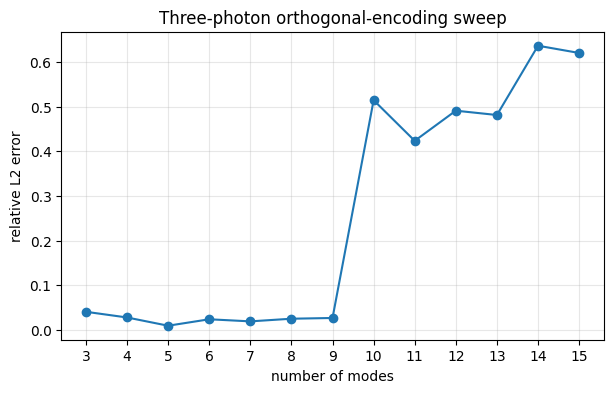

In [59]:
# Relative L2 error versus number of modes
modes = [r["n_modes"] for r in sweep_results]
rel_l2_values = [r["rel_l2"] for r in sweep_results]

plt.figure(figsize=(7, 4))
plt.plot(modes, rel_l2_values, marker="o")
plt.xlabel("number of modes")
plt.ylabel("relative L2 error")
plt.xticks(modes)
plt.title("Three-photon orthogonal-encoding sweep")
plt.grid(True, alpha=0.3)
plt.show()


best number of modes: 5
relative L2 error: 0.009230796247720718


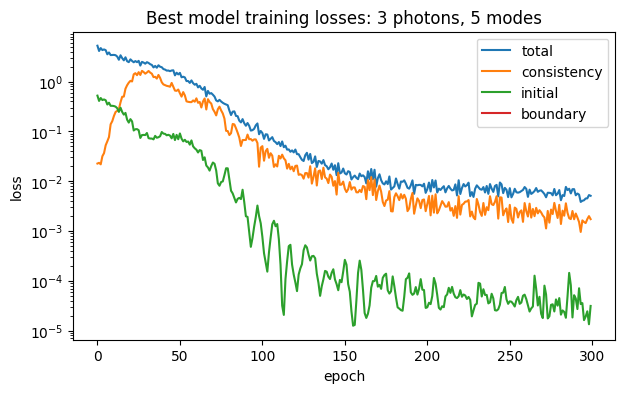

In [60]:
# Evaluate the best model on the grid and show its training losses
nx, nt = 60, 60
x = torch.linspace(0, 1, nx, device=device, dtype=dtype).reshape(-1, 1)
t = torch.linspace(0, 1, nt, device=device, dtype=dtype).reshape(-1, 1)
X, T = torch.meshgrid(x.squeeze(), t.squeeze(), indexing="ij")
xt_grid = torch.stack([X.reshape(-1), T.reshape(-1)], dim=1)

with torch.no_grad():
    U_pred, UX_hat = best_model(xt_grid)
    U_pred = U_pred.reshape(nx, nt).cpu()
    U_true = exact_u(xt_grid[:, 0:1], xt_grid[:, 1:2]).reshape(nx, nt).cpu()

rel_l2 = torch.linalg.norm(U_pred - U_true) / torch.linalg.norm(U_true)
print("best number of modes:", best_n_modes)
print("relative L2 error:", float(rel_l2))

# Plot training losses for the best model (PDE curve omitted)
hist = np.array(best_history)
plt.figure(figsize=(7, 4))
plt.semilogy(hist[:, 0], label="total")
plt.semilogy(hist[:, 2], label="consistency")
plt.semilogy(hist[:, 3], label="initial")
plt.semilogy(hist[:, 4], label="boundary")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title(f"Best model training losses: 3 photons, {best_n_modes} modes")
plt.show()


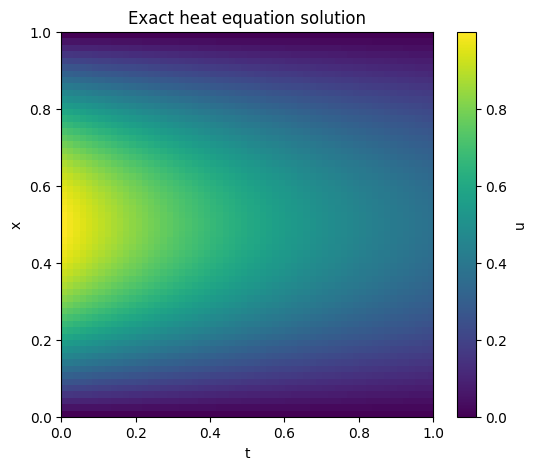

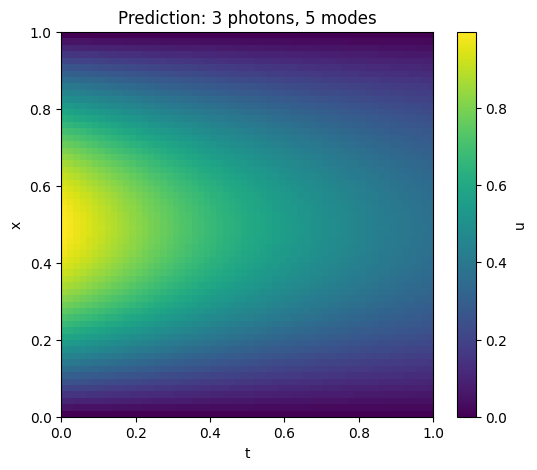

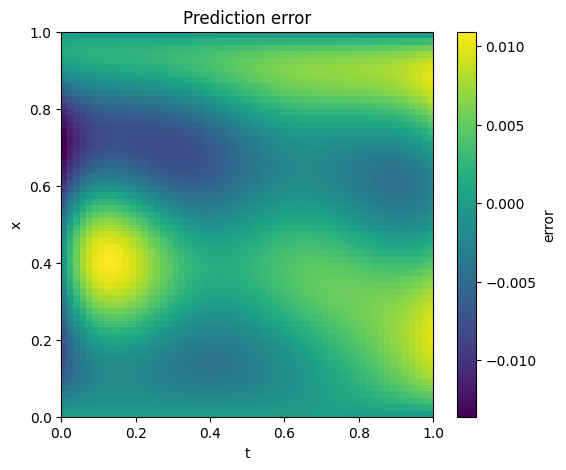

Circuit with minimum relative L2: 3 photons, 5 modes
input state: [1, 1, 1, 0, 0]
x relative-phase pattern: [1, 1, 0, -1, -1]
t relative-phase pattern: [1, -1, 0, -1, 1]
quantum output size: 35
trainable parameters: 708


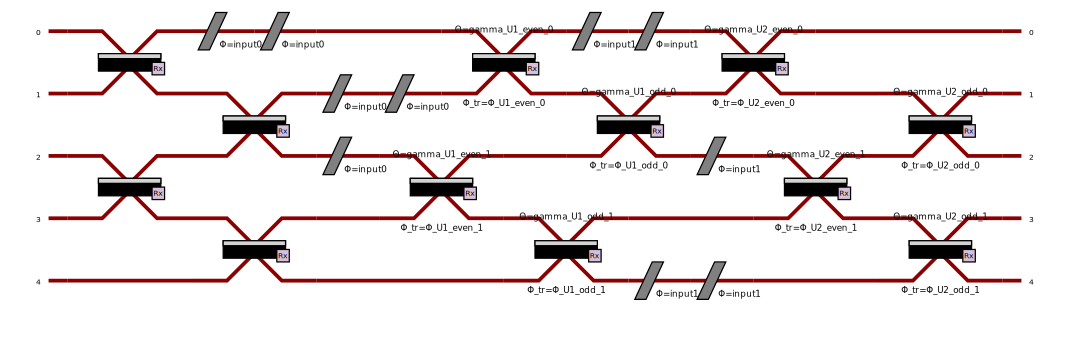

In [61]:
# Visual comparison for the best model
plt.figure(figsize=(6, 5))
plt.imshow(U_true.numpy(), origin="lower", extent=[0, 1, 0, 1], aspect="auto")
plt.colorbar(label="u")
plt.xlabel("t")
plt.ylabel("x")
plt.title("Exact heat equation solution")
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(U_pred.numpy(), origin="lower", extent=[0, 1, 0, 1], aspect="auto")
plt.colorbar(label="u")
plt.xlabel("t")
plt.ylabel("x")
plt.title(f"Prediction: 3 photons, {best_n_modes} modes")
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow((U_pred - U_true).numpy(), origin="lower", extent=[0, 1, 0, 1], aspect="auto")
plt.colorbar(label="error")
plt.xlabel("t")
plt.ylabel("x")
plt.title("Prediction error")
plt.show()

# Display the circuit corresponding to the minimum relative L2 error
print(f"Circuit with minimum relative L2: 3 photons, {best_n_modes} modes")
print("input state:", best_model.input_state)
print("x relative-phase pattern:", best_model.x_pattern)
print("t relative-phase pattern:", best_model.t_pattern)
print("quantum output size:", best_model.quantum.output_size)
print("trainable parameters:", count_trainable_parameters(best_model))
pcvl.pdisplay(best_model.circuit_to_draw, recursive=False)
